# Hand-Scored Jacobson Style Conditioning

## Import packages, preprocessing data for NaNs and filling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Set file path
CSV_FILEPATH = '../hand_scored_datasheets/Jacobson_HandScored_Sc1.csv'

# Read the CSV
df = pd.read_csv(CSV_FILEPATH)

# Forward fill the group_day column to fill empty cells
df['group_day'] = df['group_day'].replace('', np.nan)
df['group_day'] = df['group_day'].fillna(method='ffill')

# Convert W1-W6 columns to numeric, coercing errors to NaN
worm_columns = ['W1', 'W2', 'W3', 'W4', 'W5', 'W6']
for col in worm_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert BlockNum to numeric
df['BlockNum'] = pd.to_numeric(df['BlockNum'], errors='coerce')

print("Data loaded and preprocessed successfully!")
print(f"Total rows: {len(df)}")
print(f"Unique group_day values: {df['group_day'].unique()}")
print(f"BlockNum range: {df['BlockNum'].min()} to {df['BlockNum'].max()}")

Data loaded and preprocessed successfully!
Total rows: 975
Unique group_day values: ['R1_1' 'R2_1' 'R3_1' 'R4_1' 'R1_2' 'R2_2' "No further L's after this?"
 'ZK: on Mon, look at reported L/S sequence'
 'Frames temp reported in F column, delete when issue solvd' 'R3_2' 'R5_1'
 'R6_1' 'R1_3' 'R4_5' 'R4_6' 'R4_7']
BlockNum range: 1 to 10


## Define graphing function

In [2]:
def create_graphs(data, groups=['R1', 'R2', 'R3', 'R4', 'R5', 'R6'], blocks=None, 
                  error_type='SEM', figsize=(10, 6),
                  title='Performance Across Blocks',
                  ylabel='Average Score',
                  y_values='probability',
                  ylim='auto', ylim_padding=0.1,
                  save=False, filename='../figures/Fig1C_Jacobson_HandScored_Lineplot',
                  show_error_bars=True):
    """
    Creates a line graph showing average performance across blocks for different groups.
    
    NOTE: This function handles variable trial counts automatically. It collects ALL trials 
    for each block (whether 13, 20, or 25 trials) and averages all W1-W6 values found.
    
    Parameters:
    -----------
    data : pandas DataFrame
        The preprocessed dataframe containing behavioral data
    groups : list of str
        List of group prefixes to plot (e.g., ['R1', 'R3', 'R5'])
        Default includes all groups: ['R1', 'R2', 'R3', 'R4', 'R5', 'R6']
    blocks : list of int or None
        Specific blocks to include. If None, uses all available blocks
    error_type : str
        Type of error bars: 'SEM' or '95CI' (default: 'SEM')
    figsize : tuple
        Figure size (width, height) (default: (10, 6))
    title : str
        Plot title (default: 'Performance Across Blocks')
    ylabel : str
        Y-axis label (default: 'Average Score')
    y_values : str
        Type of y-axis values: 'probability' or 'counts' (default: 'probability')
        - 'probability': Average of all W1-W6 values (proportions)
        - 'counts': Sum each worm's scores, then average the 6 sums
    ylim : str, float, or tuple
        Y-axis limits. Options:
        - 'auto': Automatically determine based on data (default)
        - float: Sets max limit (min will be 0)
        - tuple (min, max): Explicitly set both limits
    ylim_padding : float
        Padding factor for auto y-limits (0.1 = 10% padding) (default: 0.1)
        Only used when ylim='auto'
    save : bool
        If True, saves the plot instead of displaying it (default: False)
    filename : str
        Filename for saving the plot (default: 'Jacobson_HandScored_Lineplot.svg')
    show_error_bars : bool
        If True, displays error bars (default: True)
    
    Returns:
    --------
    dict : Summary statistics for each group and block
    """
    
    # Validate error_type
    if error_type.upper() not in ['SEM', '95CI', 'CI']:
        raise ValueError("error_type must be 'SEM' or '95CI'")
    
    # Validate y_values
    if y_values.lower() not in ['probability', 'counts']:
        raise ValueError("y_values must be 'probability' or 'counts'")
    
    # Define styling for each group
    group_styles = {
        'R1': {
            'color': '#0072B2',      # Wong palette blue (colorblind-safe)
            'linestyle': '-',         # Solid
            'marker': 'o',            # Filled circle
            'fillstyle': 'full',
            'label': 'High responders, CC'
        },
        'R2': {
            'color': '#0072B2',      # Same blue as R1
            'linestyle': '--',        # Dashed
            'marker': 'o',            # Open circle
            'fillstyle': 'none',
            'label': 'High responders, PC'
        },
        'R3': {
            'color': '#D55E00',      # Wong palette vermillion (colorblind-safe)
            'linestyle': '-',         # Solid
            'marker': 'o',            # Filled circle
            'fillstyle': 'full',
            'label': 'Low responders, CC'
        },
        'R4': {
            'color': '#D55E00',      # Same vermillion as R3
            'linestyle': '--',        # Dashed
            'marker': 'o',            # Open circle
            'fillstyle': 'none',
            'label': 'Low responders, PC'
        },
        'R5': {
            'color': '#E69F00',      # Wong palette yellow-orange (colorblind-safe)
            'linestyle': '-',         # Solid
            'marker': 'o',            # Filled circle
            'fillstyle': 'full',
            'label': 'R5: Low responders, CC'
        },
        'R6': {
            'color': '#E69F00',      # Same yellow-orange as R5
            'linestyle': '--',        # Dashed
            'marker': 'o',            # Open circle
            'fillstyle': 'none',
            'label': 'R6: Low responders, PC'
        }
    }
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Store summary statistics
    summary_stats = {}
    
    # Store all plotted values for auto y-limit calculation
    all_means = []
    all_errors = []
    
    # Track blocks with no data for debugging
    no_data_blocks = []
    
    # Process each group
    for group in groups:
        # Check if group has defined styling
        if group not in group_styles:
            print(f"Warning: No styling defined for group {group}, skipping...")
            continue
        
        style = group_styles[group]
        
        # Filter data for this group (anything with group prefix before underscore)
        group_data = data[data['group_day'].str.startswith(group + '_', na=False)].copy()
        
        if group_data.empty:
            print(f"Warning: No data found for group {group}")
            continue
        
        # Determine which blocks to process
        if blocks is None:
            available_blocks = sorted(group_data['BlockNum'].dropna().unique())
        else:
            available_blocks = sorted([b for b in blocks if b in group_data['BlockNum'].values])
        
        block_means = []
        block_errors = []
        valid_blocks = []
        
        # Calculate statistics for each block
        for block_num in available_blocks:
            block_data = group_data[group_data['BlockNum'] == block_num]
            
            if block_data.empty:
                no_data_blocks.append(f"{group} Block {int(block_num)}")
                continue
            
            if y_values.lower() == 'probability':
                # Original method: Collect all values from W1-W6 for this block
                # NOTE: This automatically handles variable trial counts (13-25 trials)
                all_values = []
                for worm_col in worm_columns:
                    values = block_data[worm_col].dropna()
                    all_values.extend(values.tolist())
                
                if not all_values:
                    no_data_blocks.append(f"{group} Block {int(block_num)}")
                    print(f"Warning: No valid data for {group}, Block {block_num}")
                    continue
                
                # Calculate mean and error
                mean_val = np.mean(all_values)
                sem_val = np.std(all_values, ddof=1) / np.sqrt(len(all_values))
                
                if error_type.upper() == 'SEM':
                    error_val = sem_val
                    error_label = 'SEM'
                else:  # 95% CI
                    n = len(all_values)
                    t_critical = stats.t.ppf(0.975, df=n-1)
                    error_val = t_critical * sem_val
                    error_label = '95% CI'
                
                n_datapoints = len(all_values)
                std_val = np.std(all_values, ddof=1)
                
            else:  # y_values == 'counts'
                # New method: Sum each worm's scores, then average the 6 sums
                worm_sums = []
                for worm_col in worm_columns:
                    values = block_data[worm_col].dropna()
                    if len(values) > 0:
                        worm_sum = values.sum()
                        worm_sums.append(worm_sum)
                
                if not worm_sums:
                    no_data_blocks.append(f"{group} Block {int(block_num)}")
                    print(f"Warning: No valid data for {group}, Block {block_num}")
                    continue
                
                # Calculate mean and error from the worm sums (N = number of worms with data)
                mean_val = np.mean(worm_sums)
                sem_val = np.std(worm_sums, ddof=1) / np.sqrt(len(worm_sums))
                
                if error_type.upper() == 'SEM':
                    error_val = sem_val
                    error_label = 'SEM'
                else:  # 95% CI
                    n = len(worm_sums)
                    t_critical = stats.t.ppf(0.975, df=n-1)
                    error_val = t_critical * sem_val
                    error_label = '95% CI'
                
                n_datapoints = len(worm_sums)
                std_val = np.std(worm_sums, ddof=1)
            
            block_means.append(mean_val)
            block_errors.append(error_val)
            valid_blocks.append(block_num)
            
            # Store for auto y-limit calculation
            all_means.append(mean_val)
            all_errors.append(error_val)
            
            # Store statistics
            if group not in summary_stats:
                summary_stats[group] = {}
            
            summary_stats[group][f'Block_{int(block_num)}'] = {
                'mean': mean_val,
                'sem': sem_val,
                'error_value': error_val,
                'error_type': error_label,
                'n_datapoints': n_datapoints,
                'std': std_val,
                'calculation_method': y_values
            }
            
            #print(f"{group} Block {int(block_num)}: Mean={mean_val:.3f}, {error_label}={error_val:.3f}, N={n_datapoints}")
        
        # Plot the line for this group
        if valid_blocks:
            if show_error_bars:
                ax.errorbar(valid_blocks, block_means, yerr=block_errors,
                           marker=style['marker'], markersize=8, 
                           markerfacecolor=style['color'] if style['fillstyle'] == 'full' else 'none',
                           markeredgecolor=style['color'], markeredgewidth=1.5,
                           fillstyle=style['fillstyle'],
                           linestyle=style['linestyle'], linewidth=2, color=style['color'],
                           capsize=5, capthick=2, 
                           label=style['label'], alpha=0.9)
            else:
                ax.plot(valid_blocks, block_means,
                       marker=style['marker'], markersize=8, 
                       markerfacecolor=style['color'] if style['fillstyle'] == 'full' else 'none',
                       markeredgecolor=style['color'], markeredgewidth=1.5,
                       fillstyle=style['fillstyle'],
                       linestyle=style['linestyle'], linewidth=2, color=style['color'],
                       label=style['label'], alpha=0.9)
    
    # Set y-axis limits based on ylim parameter
    if ylim == 'auto':
        if all_means:
            # Calculate auto limits with padding
            max_val = max([m + e for m, e in zip(all_means, all_errors)])
            min_val = min([m - e for m, e in zip(all_means, all_errors)])
            
            # Ensure min doesn't go below 0
            y_min = max(0, min_val - ylim_padding * (max_val - min_val))
            y_max = max_val + ylim_padding * (max_val - min_val)
            
            ax.set_ylim(y_min, y_max)
            print(f"\nAuto y-limits: [{y_min:.3f}, {y_max:.3f}]")
    elif isinstance(ylim, (int, float)):
        # Single value - use as max, 0 as min
        ax.set_ylim(0, ylim)
        #print(f"\nY-limits set to: [0, {ylim}]")
    elif isinstance(ylim, (list, tuple)) and len(ylim) == 2:
        # Explicit (min, max) tuple
        ax.set_ylim(ylim[0], ylim[1])
        #print(f"\nY-limits set to: [{ylim[0]}, {ylim[1]}]")
    else:
        raise ValueError("ylim must be 'auto', a number, or a tuple (min, max)")
    
    # Formatting
    ax.set_xlabel('Block Number', fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10, framealpha=0.9)
    
    # Custom x-axis labels and ticks for blocks 1-7
    if blocks is not None and set(blocks) == {1, 2, 3, 4, 5, 6, 7}:
        # Set tick positions
        ax.set_xticks([1, 2, 3, 4, 5, 6, 7])
        
        # Create custom labels with subscripts and renumbering
        labels = ['$L_1$', '$L_2$', '1', '2', '3', '4', '5']
        ax.set_xticklabels(labels)
        
        # Add axis break symbol (||) between L2 and 1
        # Position it between x=2 and x=3
        y_min, y_max = ax.get_ylim()
        #break_y = y_min #- 0.08 * (y_max - y_min)  # Position with head right on x axis
        break_y = y_min + 0.0125 * (y_max - y_min)  # Trying to get centered

        ax.text(2.5, break_y, '||', fontsize=10, ha='center', va='top', 
                fontweight='bold', color='black')
    else:
        # Default behavior for other block selections
        if blocks is None:
            ax.set_xticks(range(1, 11))
        else:
            ax.set_xticks(blocks)
    
    # Add faint gray background grid lines
    ax.grid(True, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.set_axisbelow(True)  # Put grid lines behind data
    
    plt.tight_layout()
    
    # Print debugging info for blocks with no data
    if no_data_blocks:
        print("\n" + "="*50)
        print("DEBUGGING: Blocks with no valid data (all NaNs):")
        for block_info in no_data_blocks:
            print(f"  - {block_info}")
        print("="*50)
    
    # Save or show
    if save:
        filepath = filename if filename.endswith('.svg') else f"{filename}.svg"
        fig.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"\nPlot saved to: {filepath}")
        plt.close(fig)
    else:
        plt.show()
    
    return summary_stats

print("Graphing function defined successfully!")

group_day_list = list(df['group_day'])
groupID = [x.split('_')[0] for x in group_day_list]
df['groupID'] = groupID
df['Chronology'] = np.arange(len(df))

Graphing function defined successfully!


## Graph

In [3]:
# ==================== MASTER CONTROL CELL ====================
# Run this cell to generate your graphs

# Example 1: Plot with probability (original method)
stats_prob = create_graphs(
    df,
    groups=['R1', 'R2', 'R3', 'R4'],
    blocks=[1, 2, 3, 4, 5, 6, 7],
    error_type='SEM',
    y_values='counts',
    ylim=18,
    title='Contraction probability across blocks',
    ylabel='Average CR probability',
    save=True
)

print("\n" + "="*50)
print("Graphing complete!")
print("="*50)


Plot saved to: ../figures/Fig1C_Jacobson_HandScored_Lineplot.svg

Graphing complete!


In [1]:
# ==================== POOLED CC vs PC (no high/low split) ====================
# Same data as Fig1C above, but pooling high and low responders into a single
# CC line and a single PC line.
#   CC = R1 (high) + R3 (low)
#   PC = R2 (high) + R4 (low)
# Pooling rule matches the trend-stats cell below: each (group, W#) column is
# treated as one worm and contributes one worm-block sum.

POOL_CC = ['R1', 'R3']
POOL_PC = ['R2', 'R4']
BLOCKS  = [1, 2, 3, 4, 5, 6, 7]


def _pooled_block_stats(data, group_prefixes, blocks, worm_cols=worm_columns):
    """For each block, pool worm-level counts across the given groups and
    return per-block mean ± SEM and the number of contributing worm columns."""
    means, sems, ns = [], [], []
    for block_num in blocks:
        worm_sums = []
        for prefix in group_prefixes:
            gdata = data[data['group_day'].str.startswith(prefix + '_', na=False)]
            bdata = gdata[gdata['BlockNum'] == block_num]
            for wcol in worm_cols:
                vals = bdata[wcol].dropna()
                if len(vals) > 0:
                    worm_sums.append(vals.sum())
        if worm_sums:
            means.append(np.mean(worm_sums))
            sems.append(np.std(worm_sums, ddof=1) / np.sqrt(len(worm_sums)))
            ns.append(len(worm_sums))
        else:
            means.append(np.nan); sems.append(np.nan); ns.append(0)
    return np.array(means), np.array(sems), np.array(ns)


cc_means, cc_sems, cc_ns = _pooled_block_stats(df, POOL_CC, BLOCKS)
pc_means, pc_sems, pc_ns = _pooled_block_stats(df, POOL_PC, BLOCKS)

n_cc = int(cc_ns.max()) if cc_ns.size else 0
n_pc = int(pc_ns.max()) if pc_ns.size else 0

# Colors match Fig1D_Original_Jacobson.svg so the modern and historical plots
# read as a matched pair: blue = CC, vermillion = PC.
COLOR_CC = '#0072B2'   # Wong blue
COLOR_PC = '#D55E00'   # Wong vermillion

fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(BLOCKS, cc_means, yerr=cc_sems,
            marker='o', markersize=8,
            markerfacecolor=COLOR_CC, markeredgecolor=COLOR_CC, markeredgewidth=1.5,
            linestyle='-', linewidth=2.5, color=COLOR_CC,
            capsize=5, capthick=2,
            label=f'Conditioning (CC), n = {n_cc} worms', alpha=0.9, zorder=5)

ax.errorbar(BLOCKS, pc_means, yerr=pc_sems,
            marker='s', markersize=8,
            markerfacecolor='none', markeredgecolor=COLOR_PC, markeredgewidth=2,
            linestyle='--', linewidth=2.5, color=COLOR_PC,
            capsize=5, capthick=2,
            label=f'Pseudoconditioning (PC), n = {n_pc} worms', alpha=0.9, zorder=5)

ax.set_xticks(BLOCKS)
ax.set_xticklabels(['$L_1$', '$L_2$', '1', '2', '3', '4', '5'])
ax.set_xlabel('Block Number', fontsize=12, fontweight='bold')
ax.set_ylabel('Average CR counts (sum per worm)', fontsize=12, fontweight='bold')
ax.set_title('CC vs PC across blocks (responders pooled)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 18)

y_min, y_max = ax.get_ylim()
break_y = y_min + 0.0125 * (y_max - y_min)
ax.text(2.5, break_y, '||', fontsize=10, ha='center', va='top',
        fontweight='bold', color='black')

ax.legend(loc='best', fontsize=10, framealpha=0.9)
ax.grid(True, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
savepath = '../figures/Fig1C_Jacobson_HandScored_Lineplot_PooledCCvsPC.svg'
fig.savefig(savepath, dpi=300, bbox_inches='tight')
print(f'\nPlot saved to: {savepath}')
plt.show()

print('\nPer-block means (counts per worm, mean ± SEM):')
for i, b in enumerate(BLOCKS):
    print(f'  Block {b}:  CC = {cc_means[i]:5.2f} ± {cc_sems[i]:4.2f}  (n={cc_ns[i]})'
          f'    PC = {pc_means[i]:5.2f} ± {pc_sems[i]:4.2f}  (n={pc_ns[i]})')


NameError: name 'worm_columns' is not defined

## Trend & responder-level statistics
Tests run on **conditioning blocks only** (blocks 3-7, i.e. the CC/PC blocks, excluding LO baseline).

1. **Upward trend in CC** (R1 + R3): per-worm slope t-test + Page's L
2. **Upward trend in PC** (R2 + R4): per-worm slope t-test + Page's L
3. **High vs Low responders**: 2x2 comparison (responder level x condition type) on mean CR probability

#### Page's L: Do values tend to be ordered low and high across blocks? 

Nonparametric. Measures each worm's scores across blocks and checks if higher ranks appear consistently in later blocks. Does not assume linearity detects any consistent upward ordering. 

#### Slope t-test: Do values lienarly incraese across blocks?

Parametric assumes slopes normally distributed. Calcupates regression slop per worm across blocks. Tests whether mean of all worms' slopes is significantly diff from zero using 1-sample t-test. 

#### Welch's T: Is the mean value in group A different from that of group B? 

Assumes data from each group ~ normal, does NOT assume equal variances. Format: t(df) = value, p = value, d = value.

Cohen's d: Measures effect size ie how far apart the two groups means are in SD units. (0.2 small, 0.5 med, 0.8 large).

#### Mann-Whitney: Compares group ranks: if I picked random obs from group A and a random obs from group B, is one consistently larger than the other. 

No distribution assumptions, just ranks all values from both groups and see if one is systematically higher. Format: U = value, p = value. 

In [4]:
import numpy as np
from scipy import stats as sp_stats

worm_columns = ['W1', 'W2', 'W3', 'W4', 'W5', 'W6']
COND_BLOCKS = [3, 4, 5, 6, 7]

# ── Helper: get per-worm, per-block CR probability ──────────────────────────
def _worm_block_probs(data, group_prefixes, blocks):
    worm_data = {}
    for gp in group_prefixes:
        gdata = data[data['group_day'].str.startswith(gp + '_', na=False)].copy()
        if gdata.empty:
            continue
        for wc in worm_columns:
            key = (gp, wc)
            worm_data[key] = {}
            for blk in blocks:
                vals = gdata.loc[gdata['BlockNum'] == blk, wc].dropna()
                if len(vals):
                    worm_data[key][blk] = float(vals.mean())
    return worm_data


def _get_trend_stats(data, group_prefixes, blocks):
    """Per-worm slope two-sided t-test + Page's L."""
    wd = _worm_block_probs(data, group_prefixes, blocks)
    slopes = []
    for (gp, wc), blk_scores in wd.items():
        x = sorted(blk_scores.keys())
        y = [blk_scores[b] for b in x]
        if len(x) >= 2:
            slopes.append(sp_stats.linregress(x, y).slope)
    sarr = np.array(slopes)
    n = len(sarr)
    mu = np.mean(sarr)
    se = np.std(sarr, ddof=1) / np.sqrt(n)
    t_s, p2 = sp_stats.ttest_1samp(sarr, 0)

    mat = []
    for (gp, wc), blk_scores in wd.items():
        row = [blk_scores.get(b) for b in blocks]
        if all(v is not None for v in row):
            mat.append(row)
    page_L, page_p = None, None
    if len(mat) >= 2 and len(blocks) >= 3:
        try:
            pr = sp_stats.page_trend_test(np.array(mat, dtype=float))
            page_L, page_p = pr.statistic, pr.pvalue
        except:
            pass
    return dict(n=n, mu=mu, se=se, t=t_s, df=n-1, p2=p2,
                page_L=page_L, page_p=page_p)


def _mean_cr_prob(data, group_prefixes, blocks):
    """One mean CR probability per worm (averaged across all blocks)."""
    means = []
    for gp in group_prefixes:
        gdata = data[data['group_day'].str.startswith(gp + '_', na=False)].copy()
        if gdata.empty:
            continue
        for wc in worm_columns:
            vals_across_blocks = []
            for blk in blocks:
                v = gdata.loc[gdata['BlockNum'] == blk, wc].dropna()
                if len(v):
                    vals_across_blocks.extend(v.tolist())
            if vals_across_blocks:
                means.append(np.mean(vals_across_blocks))
    return np.array(means)


# ══════════════════════════════════════════════════════════════════════════════
#  1. TREND: per-worm slope t-test (two-sided) + Page's L for CC and PC
# ══════════════════════════════════════════════════════════════════════════════
cc = _get_trend_stats(df, ['R1', 'R3'], COND_BLOCKS)
pc = _get_trend_stats(df, ['R2', 'R4'], COND_BLOCKS)

# ══════════════════════════════════════════════════════════════════════════════
#  2. GROUP DIFFERENCE: one-way ANOVA, main effect of condition (CC vs PC)
# ══════════════════════════════════════════════════════════════════════════════
cc_all = np.concatenate([_mean_cr_prob(df, ['R1'], COND_BLOCKS),
                         _mean_cr_prob(df, ['R3'], COND_BLOCKS)])
pc_all = np.concatenate([_mean_cr_prob(df, ['R2'], COND_BLOCKS),
                         _mean_cr_prob(df, ['R4'], COND_BLOCKS)])
f_cond, p_cond = sp_stats.f_oneway(cc_all, pc_all)
df_between = 1
df_within = len(cc_all) + len(pc_all) - 2

# ══════════════════════════════════════════════════════════════════════════════
#  3. SLOPE COMPARISON: high vs low responders within CC and PC
# ══════════════════════════════════════════════════════════════════════════════

def _get_slopes(data, group_prefixes, blocks):
    """Get per-worm slopes for a set of groups across specified blocks."""
    slopes = []
    for gp in group_prefixes:
        gdata = data[data['group_day'].str.startswith(gp + '_', na=False)]
        if gdata.empty:
            continue
        for wc in worm_columns:
            worm_vals = {}
            for blk in blocks:
                vals = gdata.loc[gdata['BlockNum'] == blk, wc].dropna()
                if len(vals):
                    worm_vals[blk] = float(vals.mean())
            if len(worm_vals) >= 2:
                x = sorted(worm_vals.keys())
                y = [worm_vals[b] for b in x]
                slopes.append(sp_stats.linregress(x, y).slope)
    return np.array(slopes)

def _cohens_d(a, b):
    return (np.mean(a) - np.mean(b)) / np.sqrt((np.var(a, ddof=1) + np.var(b, ddof=1)) / 2)

cc_hi_s = _get_slopes(df, ['R1'], COND_BLOCKS)
cc_lo_s = _get_slopes(df, ['R3'], COND_BLOCKS)
t_hl_cc, p_hl_cc = sp_stats.ttest_ind(cc_hi_s, cc_lo_s, equal_var=False)
d_hl_cc = _cohens_d(cc_hi_s, cc_lo_s)

pc_hi_s = _get_slopes(df, ['R2'], COND_BLOCKS)
pc_lo_s = _get_slopes(df, ['R4'], COND_BLOCKS)
t_hl_pc, p_hl_pc = sp_stats.ttest_ind(pc_hi_s, pc_lo_s, equal_var=False)
d_hl_pc = _cohens_d(pc_hi_s, pc_lo_s)

# ══════════════════════════════════════════════════════════════════════════════
#  REPORTING SUMMARY
# ══════════════════════════════════════════════════════════════════════════════
print("█" * 70)
print("  REPORTING SUMMARY")
print("█" * 70)

print(f"""
── CC (conditioning) trend ──
  Per-worm slope t-test (two-sided): t({cc['df']}) = {cc['t']:+.2f}, p = {cc['p2']:.3f}, n = {cc['n']} worms
  Page's L = {cc['page_L']:.1f}, p = {cc['page_p']:.3f}

── PC (pseudoconditioning) trend ──
  Per-worm slope t-test (two-sided): t({pc['df']}) = {pc['t']:+.2f}, p = {pc['p2']:.3f}, n = {pc['n']} worms
  Page's L = {pc['page_L']:.1f}, p = {pc['page_p']:.3f}

── CC vs PC (main effect of condition) ──
  ANOVA: F({df_between}, {df_within}) = {f_cond:.2f}, p = {p_cond:.3f}

── High vs Low responder slopes (CC) ──
  High CC: n={len(cc_hi_s)}, mean slope = {np.mean(cc_hi_s):+.4f} ± {np.std(cc_hi_s, ddof=1)/np.sqrt(len(cc_hi_s)):.4f} SEM
  Low  CC: n={len(cc_lo_s)}, mean slope = {np.mean(cc_lo_s):+.4f} ± {np.std(cc_lo_s, ddof=1)/np.sqrt(len(cc_lo_s)):.4f} SEM
  Welch's t({len(cc_hi_s)+len(cc_lo_s)-2}) = {t_hl_cc:+.2f}, p = {p_hl_cc:.3f}, d = {d_hl_cc:+.2f}

── High vs Low responder slopes (PC) ──
  High PC: n={len(pc_hi_s)}, mean slope = {np.mean(pc_hi_s):+.4f} ± {np.std(pc_hi_s, ddof=1)/np.sqrt(len(pc_hi_s)):.4f} SEM
  Low  PC: n={len(pc_lo_s)}, mean slope = {np.mean(pc_lo_s):+.4f} ± {np.std(pc_lo_s, ddof=1)/np.sqrt(len(pc_lo_s)):.4f} SEM
  Welch's t({len(pc_hi_s)+len(pc_lo_s)-2}) = {t_hl_pc:+.2f}, p = {p_hl_pc:.3f}, d = {d_hl_pc:+.2f}
""")

print("█" * 70)

██████████████████████████████████████████████████████████████████████
  REPORTING SUMMARY
██████████████████████████████████████████████████████████████████████

── CC (conditioning) trend ──
  Per-worm slope t-test (two-sided): t(11) = -3.86, p = 0.003, n = 12 worms
  Page's L = 491.0, p = 0.998

── PC (pseudoconditioning) trend ──
  Per-worm slope t-test (two-sided): t(11) = -1.82, p = 0.097, n = 12 worms
  Page's L = 510.0, p = 0.961

── CC vs PC (main effect of condition) ──
  ANOVA: F(1, 22) = 2.88, p = 0.104

── High vs Low responder slopes (CC) ──
  High CC: n=6, mean slope = -0.0200 ± 0.0079 SEM
  Low  CC: n=6, mean slope = -0.0173 ± 0.0063 SEM
  Welch's t(10) = -0.27, p = 0.794, d = -0.15

── High vs Low responder slopes (PC) ──
  High PC: n=6, mean slope = -0.0134 ± 0.0155 SEM
  Low  PC: n=6, mean slope = -0.0245 ± 0.0150 SEM
  Welch's t(10) = +0.51, p = 0.619, d = +0.30

██████████████████████████████████████████████████████████████████████


## Generate supplementary high-low sorting box and whisker
The data is taken from Phenotest_Stats. The average responses of worms across two LO blocks were determined and then listed in decreasing order. That list was evenly trisected to make high, medium, and low groups. Note that what got labeled as "medium" is actually the "low" in the graph above; we discarded the original low group because no one wants to score that shit and it's all flat so far anyway. There's not good reason to think that the super low responders would respond more to conditioning (the opposite is indicated by the literature). 

Saved: ../figures/Supp2_high_low_responders_boxplot.svg


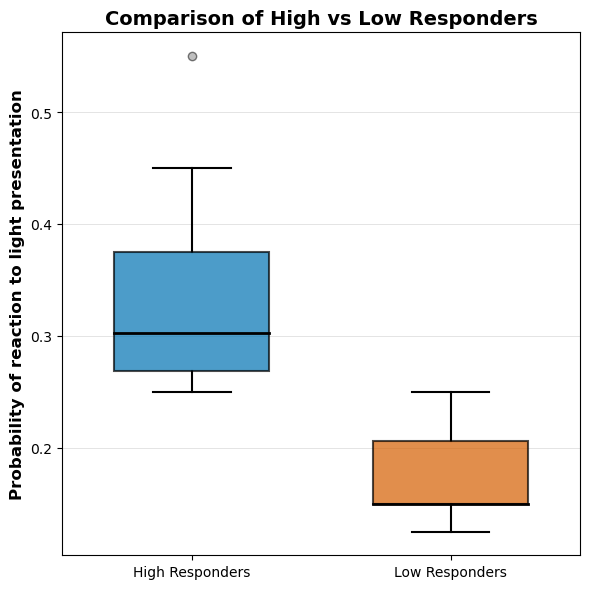


SUMMARY STATISTICS

High Responders (n=12):
  Mean: 0.340
  Median: 0.302
  Std Dev: 0.096
  Min: 0.250
  Max: 0.550

Low Responders (n=12):
  Mean: 0.171
  Median: 0.150
  Std Dev: 0.042
  Min: 0.125
  Max: 0.250

Independent t-test:
  t-statistic: 5.5818197572
  p-value: 0.0000130405


In [5]:
# Copy over the list of scores for the high group
high_LO_scores = [0.55, 0.45, 0.35, 0.3, 0.275, 0.25, 0.45, 0.35, 0.305, 0.3, 0.25, 0.25]

# Copy over the list of scores for the low group
low_LO_scores = [0.25, 0.225, 0.15, 0.15, 0.15, 0.125, 0.225, 0.2, 0.15, 0.15, 0.15, 0.125]

# Create figure
fig, ax = plt.subplots(figsize=(6, 6))

# Create box plot
bp = ax.boxplot([high_LO_scores, low_LO_scores], 
                 labels=['High Responders', 'Low Responders'],
                 patch_artist=True,  # Enables color filling
                 widths=0.6,
                 showmeans=False,  # Show mean as well as median
                 meanline=False,  # Show mean as a point, not line
                 meanprops=dict(marker='D', markerfacecolor='white', 
                               markeredgecolor='black', markersize=6))

# Color the boxes
colors = ['#0072B2', '#D55E00']  # High (blue), Low (vermillion) - Wong colorblind-safe palette
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# Style the whiskers, caps, and medians
for whisker in bp['whiskers']:
    whisker.set(color='black', linewidth=1.5)

for cap in bp['caps']:
    cap.set(color='black', linewidth=1.5)

for median in bp['medians']:
    median.set(color='black', linewidth=2)

# Style the outlier markers (if any)
for flier in bp['fliers']:
    flier.set(marker='o', markerfacecolor='gray', 
             markeredgecolor='black', markersize=6, alpha=0.5)

# Formatting
ax.set_ylabel('Probability of reaction to light presentation', fontsize=12, fontweight='bold')
ax.set_title('Comparison of High vs Low Responders', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
ax.set_axisbelow(True)

# Add sample size annotations
# ax.text(1, max(high_LO_scores) * 1.02, f'n={len(high_LO_scores)}', 
#         ha='center', va='bottom', fontsize=10, style='italic')
# ax.text(2, max(low_LO_scores) * 1.02, f'n={len(low_LO_scores)}', 
#         ha='center', va='bottom', fontsize=10, style='italic')

plt.tight_layout()
fig.savefig("../figures/Supp2_high_low_responders_boxplot.svg", dpi=300, bbox_inches='tight')
print("Saved: ../figures/Supp2_high_low_responders_boxplot.svg")
plt.show()

# Print summary statistics
print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)
print(f"\nHigh Responders (n={len(high_LO_scores)}):")
print(f"  Mean: {np.mean(high_LO_scores):.3f}")
print(f"  Median: {np.median(high_LO_scores):.3f}")
print(f"  Std Dev: {np.std(high_LO_scores, ddof=1):.3f}")
print(f"  Min: {np.min(high_LO_scores):.3f}")
print(f"  Max: {np.max(high_LO_scores):.3f}")

print(f"\nLow Responders (n={len(low_LO_scores)}):")
print(f"  Mean: {np.mean(low_LO_scores):.3f}")
print(f"  Median: {np.median(low_LO_scores):.3f}")
print(f"  Std Dev: {np.std(low_LO_scores, ddof=1):.3f}")
print(f"  Min: {np.min(low_LO_scores):.3f}")
print(f"  Max: {np.max(low_LO_scores):.3f}")

# Optional: Perform t-test
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(high_LO_scores, low_LO_scores)
print(f"\nIndependent t-test:")
print(f"  t-statistic: {t_stat:.10f}")
print(f"  p-value: {p_value:.10f}")
print("="*50)

## Duplicate box and whisker code, but with the extra discarded data

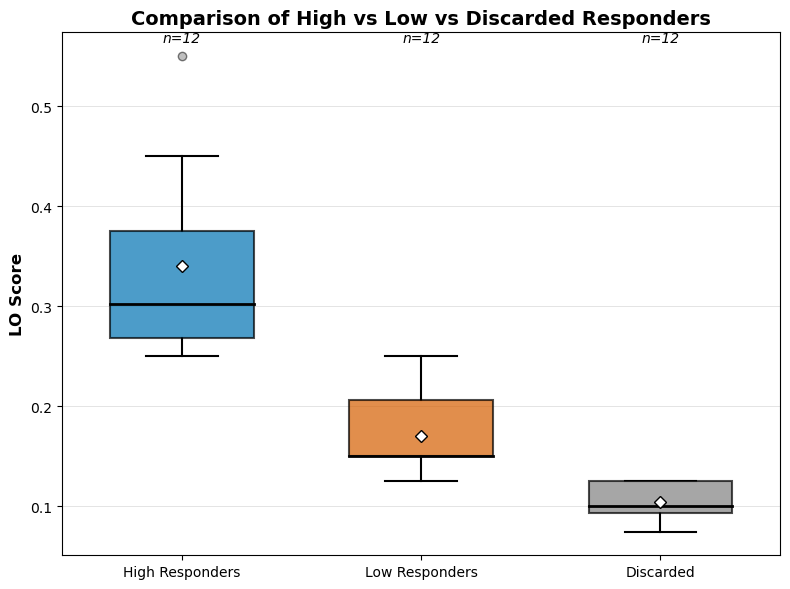


SUMMARY STATISTICS

High Responders (n=12):
  Mean: 0.340
  Median: 0.302
  Std Dev: 0.096
  Min: 0.250
  Max: 0.550

Low Responders (n=12):
  Mean: 0.171
  Median: 0.150
  Std Dev: 0.042
  Min: 0.125
  Max: 0.250

Discarded (n=12):
  Mean: 0.104
  Median: 0.100
  Std Dev: 0.021
  Min: 0.075
  Max: 0.125

Pairwise t-tests:

  High vs Low:
    t-statistic: 5.5818197572
    p-value: 1.304050986e-05

  High vs Discarded:
    t-statistic: 8.3127499606
    p-value: 0.0000000311

  Low vs Discarded:
    t-statistic: 4.8851209585
    p-value: 0.0000696072


In [6]:
# ==================== BOX AND WHISKER PLOT ====================

# Copy over the list of scores for the high group
high_LO_scores = [0.55, 0.45, 0.35, 0.3, 0.275, 0.25, 0.45, 0.35, 0.305, 0.3, 0.25, 0.25]

# Copy over the list of scores for the low group
low_LO_scores = [0.25, 0.225, 0.15, 0.15, 0.15, 0.125, 0.225, 0.2, 0.15, 0.15, 0.15, 0.125]

# Copy over the list of scores for the discarded group
discarded_LO_scores = [0.125, 0.125, 0.125, 0.1, 0.1, 0.075, 0.125, 0.125, 0.1, 0.1, 0.075, 0.075]

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Create box plot
bp = ax.boxplot([high_LO_scores, low_LO_scores, discarded_LO_scores], 
                 labels=['High Responders', 'Low Responders', 'Discarded'],
                 patch_artist=True,  # Enables color filling
                 widths=0.6,
                 showmeans=True,  # Show mean as well as median
                 meanline=False,  # Show mean as a point, not line
                 meanprops=dict(marker='D', markerfacecolor='white', 
                               markeredgecolor='black', markersize=6))

# Color the boxes
colors = ['#0072B2', '#D55E00', '#808080']  # High (blue), Low (vermillion), Discarded (gray) - Wong colorblind-safe palette
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# Style the whiskers, caps, and medians
for whisker in bp['whiskers']:
    whisker.set(color='black', linewidth=1.5)

for cap in bp['caps']:
    cap.set(color='black', linewidth=1.5)

for median in bp['medians']:
    median.set(color='black', linewidth=2)

# Style the outlier markers (if any)
for flier in bp['fliers']:
    flier.set(marker='o', markerfacecolor='gray', 
             markeredgecolor='black', markersize=6, alpha=0.5)

# Formatting
ax.set_ylabel('LO Score', fontsize=12, fontweight='bold')
ax.set_title('Comparison of High vs Low vs Discarded Responders', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
ax.set_axisbelow(True)

# Add sample size annotations
max_high = max(high_LO_scores)
max_low = max(low_LO_scores)
max_discarded = max(discarded_LO_scores)
overall_max = max(max_high, max_low, max_discarded)

ax.text(1, overall_max * 1.02, f'n={len(high_LO_scores)}', 
        ha='center', va='bottom', fontsize=10, style='italic')
ax.text(2, overall_max * 1.02, f'n={len(low_LO_scores)}', 
        ha='center', va='bottom', fontsize=10, style='italic')
ax.text(3, overall_max * 1.02, f'n={len(discarded_LO_scores)}', 
        ha='center', va='bottom', fontsize=10, style='italic')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)
print(f"\nHigh Responders (n={len(high_LO_scores)}):")
print(f"  Mean: {np.mean(high_LO_scores):.3f}")
print(f"  Median: {np.median(high_LO_scores):.3f}")
print(f"  Std Dev: {np.std(high_LO_scores, ddof=1):.3f}")
print(f"  Min: {np.min(high_LO_scores):.3f}")
print(f"  Max: {np.max(high_LO_scores):.3f}")

print(f"\nLow Responders (n={len(low_LO_scores)}):")
print(f"  Mean: {np.mean(low_LO_scores):.3f}")
print(f"  Median: {np.median(low_LO_scores):.3f}")
print(f"  Std Dev: {np.std(low_LO_scores, ddof=1):.3f}")
print(f"  Min: {np.min(low_LO_scores):.3f}")
print(f"  Max: {np.max(low_LO_scores):.3f}")

print(f"\nDiscarded (n={len(discarded_LO_scores)}):")
print(f"  Mean: {np.mean(discarded_LO_scores):.3f}")
print(f"  Median: {np.median(discarded_LO_scores):.3f}")
print(f"  Std Dev: {np.std(discarded_LO_scores, ddof=1):.3f}")
print(f"  Min: {np.min(discarded_LO_scores):.3f}")
print(f"  Max: {np.max(discarded_LO_scores):.3f}")

# Optional: Perform pairwise t-tests
from scipy.stats import ttest_ind
print(f"\nPairwise t-tests:")

t_stat_h_l, p_value_h_l = ttest_ind(high_LO_scores, low_LO_scores)
print(f"\n  High vs Low:")
print(f"    t-statistic: {t_stat_h_l:.10f}")
print(f"    p-value: {p_value_h_l:.10}")

t_stat_h_d, p_value_h_d = ttest_ind(high_LO_scores, discarded_LO_scores)
print(f"\n  High vs Discarded:")
print(f"    t-statistic: {t_stat_h_d:.10f}")
print(f"    p-value: {p_value_h_d:.10f}")

t_stat_l_d, p_value_l_d = ttest_ind(low_LO_scores, discarded_LO_scores)
print(f"\n  Low vs Discarded:")
print(f"    t-statistic: {t_stat_l_d:.10f}")
print(f"    p-value: {p_value_l_d:.10f}")

print("="*50)

# Modernize Jacobson's origianl plot

Saved: ../figures/Fig1D_Original_Jacobson.svg


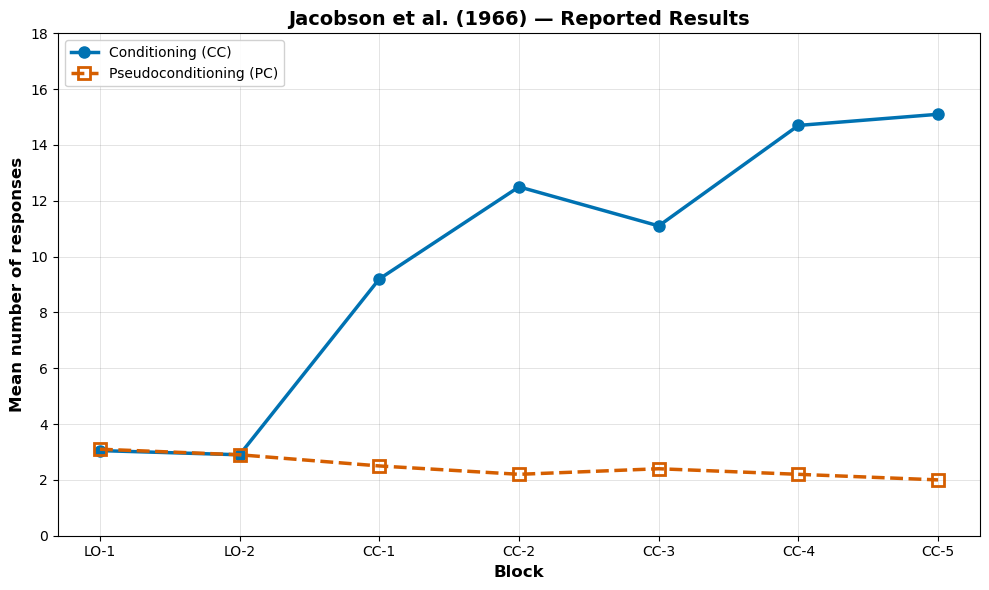

  1. TREND: CC (conditioning) — Jacobson reported means
  Linear regression on 5 block means:
    Slope     : +1.400 responses/block
    Intercept : 8.320
    R-squared : 0.8017
    t(3) = +3.483, p = 0.0400
    * SIGNIFICANT UPWARD TREND

  2. TREND: PC (pseudoconditioning) — Jacobson reported means
  Linear regression on 5 block means:
    Slope     : -0.100 responses/block
    Intercept : 2.560
    R-squared : 0.6579
    t(3) = -2.402, p = 0.0957
    * No significant trend

  3. CC vs PC COMPARISON — Jacobson reported means
  Paired t-test on block means (n=5 blocks):
    CC mean: 12.52, PC mean: 2.26
    Mean diff: +10.26
    t(4) = +8.642, p = 0.0010, Cohen's d_z = +3.865

  Slope comparison (interaction test):
    CC slope: +1.400, PC slope: -0.100
    Interaction (slope diff): -1.500
    t(6) = -3.712, p = 0.0100
    * SIGNIFICANT DIFFERENCE in trends between CC and PC

  CAVEAT: These tests are on published group means only (N=5 blocks).
  No individual worm data is available f

In [7]:
# Ground truth plot numbers from Jacobson et al. (1966)
CC_L1 = 3.05
CC_L2 = 2.9
CC1 = 9.2
CC2 = 12.5
CC3 = 11.1
CC4 = 14.7
CC5 = 15.1  

PC_L1 = 3.1
PC_L2 = 2.9
PC1 = 2.5
PC2 = 2.2
PC3 = 2.4
PC4 = 2.2
PC5 = 2.0

# ── Plot: Jacobson et al. CC vs PC ──────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

blocks = [1, 2, 3, 4, 5, 6, 7]
block_labels = ['LO-1', 'LO-2', 'CC-1', 'CC-2', 'CC-3', 'CC-4', 'CC-5']

cc_vals = [CC_L1, CC_L2, CC1, CC2, CC3, CC4, CC5]
pc_vals = [PC_L1, PC_L2, PC1, PC2, PC3, PC4, PC5]

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(blocks, cc_vals,
        color='#0072B2', linestyle='-', linewidth=2.5,
        marker='o', markersize=8, markerfacecolor='#0072B2', markeredgecolor='#0072B2',
        label='Conditioning (CC)', zorder=5)

ax.plot(blocks, pc_vals,
        color='#D55E00', linestyle='--', linewidth=2.5,
        marker='s', markersize=8, markerfacecolor='none', markeredgecolor='#D55E00',
        markeredgewidth=2, label='Pseudoconditioning (PC)', zorder=5)

ax.set_xticks(blocks)
ax.set_xticklabels(block_labels, fontsize=10)
ax.set_xlabel('Block', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean number of responses', fontsize=12, fontweight='bold')
ax.set_title('Jacobson et al. (1966) — Reported Results', fontsize=14, fontweight='bold')
ax.set_ylim(0, 18)
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.grid(True, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
fig.savefig("../figures/Fig1D_Original_Jacobson.svg", dpi=300, bbox_inches='tight')
print("Saved: ../figures/Fig1D_Original_Jacobson.svg")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
#  STATISTICS ON JACOBSON ET AL. REPORTED MEANS
#  NOTE: Only group-level means are available (no individual worm data),
#  so these are regressions on N=5 block means, not per-subject analyses.
# ══════════════════════════════════════════════════════════════════════════════
from scipy import stats as sp_stats

sep = "=" * 65
cond_blocks = np.array([1, 2, 3, 4, 5], dtype=float)
cc_cond = np.array([CC1, CC2, CC3, CC4, CC5])
pc_cond = np.array([PC1, PC2, PC3, PC4, PC5])

# ── 1. Upward trend in CC ────────────────────────────────────────────────────
print(sep)
print("  1. TREND: CC (conditioning) — Jacobson reported means")
print(sep)
res_cc = sp_stats.linregress(cond_blocks, cc_cond)
print(f"  Linear regression on 5 block means:")
print(f"    Slope     : {res_cc.slope:+.3f} responses/block")
print(f"    Intercept : {res_cc.intercept:.3f}")
print(f"    R-squared : {res_cc.rvalue**2:.4f}")
print(f"    t(3) = {res_cc.slope/res_cc.stderr:+.3f}, p = {res_cc.pvalue:.4f}")
if res_cc.pvalue < 0.05 and res_cc.slope > 0:
    print("    * SIGNIFICANT UPWARD TREND")
else:
    print("    * No significant trend")

# ── 2. Upward trend in PC ────────────────────────────────────────────────────
print(f"\n{sep}")
print("  2. TREND: PC (pseudoconditioning) — Jacobson reported means")
print(sep)
res_pc = sp_stats.linregress(cond_blocks, pc_cond)
print(f"  Linear regression on 5 block means:")
print(f"    Slope     : {res_pc.slope:+.3f} responses/block")
print(f"    Intercept : {res_pc.intercept:.3f}")
print(f"    R-squared : {res_pc.rvalue**2:.4f}")
print(f"    t(3) = {res_pc.slope/res_pc.stderr:+.3f}, p = {res_pc.pvalue:.4f}")
if res_pc.pvalue < 0.05 and res_pc.slope > 0:
    print("    * SIGNIFICANT UPWARD TREND")
else:
    print("    * No significant trend")

# ── 3. CC vs PC difference ───────────────────────────────────────────────────
print(f"\n{sep}")
print("  3. CC vs PC COMPARISON — Jacobson reported means")
print(sep)

# Paired t-test on block means (CC vs PC at each block)
t_paired, p_paired = sp_stats.ttest_rel(cc_cond, pc_cond)
d_z = np.mean(cc_cond - pc_cond) / np.std(cc_cond - pc_cond, ddof=1)
print(f"  Paired t-test on block means (n=5 blocks):")
print(f"    CC mean: {np.mean(cc_cond):.2f}, PC mean: {np.mean(pc_cond):.2f}")
print(f"    Mean diff: {np.mean(cc_cond - pc_cond):+.2f}")
print(f"    t(4) = {t_paired:+.3f}, p = {p_paired:.4f}, Cohen's d_z = {d_z:+.3f}")

# Slope comparison (ANCOVA-style: test interaction in combined regression)
# Pool both groups and test Group x Block interaction
all_blocks = np.concatenate([cond_blocks, cond_blocks])
all_vals = np.concatenate([cc_cond, pc_cond])
group_code = np.array([0]*5 + [1]*5, dtype=float)  # 0=CC, 1=PC
interaction = all_blocks * group_code

X = np.column_stack([np.ones(10), all_blocks, group_code, interaction])
from numpy.linalg import lstsq
beta, residuals, rank, sv = lstsq(X, all_vals, rcond=None)
y_pred = X @ beta
ss_res = np.sum((all_vals - y_pred)**2)
df_res = 10 - 4
mse = ss_res / df_res

# SE of interaction coefficient
XtX_inv = np.linalg.inv(X.T @ X)
se_inter = np.sqrt(mse * XtX_inv[3, 3])
t_inter = beta[3] / se_inter
p_inter = 2 * sp_stats.t.sf(abs(t_inter), df=df_res)

print(f"\n  Slope comparison (interaction test):")
print(f"    CC slope: {res_cc.slope:+.3f}, PC slope: {res_pc.slope:+.3f}")
print(f"    Interaction (slope diff): {beta[3]:+.3f}")
print(f"    t({df_res}) = {t_inter:+.3f}, p = {p_inter:.4f}")
if p_inter < 0.05:
    print("    * SIGNIFICANT DIFFERENCE in trends between CC and PC")
else:
    print("    * No significant difference in trends")

print(f"\n{sep}")
print("  CAVEAT: These tests are on published group means only (N=5 blocks).")
print("  No individual worm data is available from Jacobson et al.")
print("  Results characterize the reported trend, not subject-level inference.")
print(sep)